# ML Project - Urban Air Pollution

## TODO Project
- clean up jpnb: clean commenting, only relevant plots, clear md descriptions
- finish pres
- push pres and jpnb

## Questions
- fix issue re install xgboost & lightgbm
- top 3 features

## Next Steps
- treat outliers

## 1. Init

In [54]:
# import libraries

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor


from xgboost import XGBRegressor
from lightgbm import LGBMRegressor 

# tbd - for optimization 
#from catboost import CatBoostRegressor
#import shap


In [2]:
# load data set

df_raw = pd.read_csv("data/Train.csv")

In [3]:
# get shape 

df_raw.shape

(30557, 82)

In [4]:
# see dataframe

df_raw.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# define feature variable and target variable

# target-related columns, use for hyperparameterization?
target_cols = ['target', 'target_min', 'target_max', 'target_variance', 'target_count']

# drop target-related cols
X = df_raw.drop(target_cols, axis=1) #inplace=True?

# use only target column
Y = df_raw['target']


In [6]:
# train-test split 

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42) # stratify=Y ?

## 2. Data Cleaning & EDA

In [7]:
# check data set

X_train.head()

,Place_ID X Date,Date,Place_ID,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
18386,J8IR9R2 X 2020-02-01,2020-02-01,J8IR9R2,15.500000,73.750000,0.004229,5.585741,-0.978223,-1.065103,0.000069,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13906,EE8C6RP X 2020-02-07,2020-02-07,EE8C6RP,13.200000,69.500000,0.005473,10.474451,-1.074905,-1.208772,0.000070,...,55.364644,-173.368951,42.559485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27896,V2J713I X 2020-01-11,2020-01-11,V2J713I,9.108644,60.587501,0.003550,6.236047,1.440190,-0.529011,0.000232,...,26.080296,-168.388678,57.430464,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3463,2USU80I X 2020-02-04,2020-02-04,2USU80I,9.940000,57.140002,0.003854,8.377051,1.678333,-1.798787,0.000067,...,34.882890,-156.722085,51.604267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6706,6PWJJ6D X 2020-03-17,2020-03-17,6PWJJ6D,14.900001,70.300003,0.006390,10.458612,0.195703,-0.708057,0.000099,...,59.477474,-157.914741,41.350113,NaN,NaN,NaN,NaN,NaN,NaN,NaN


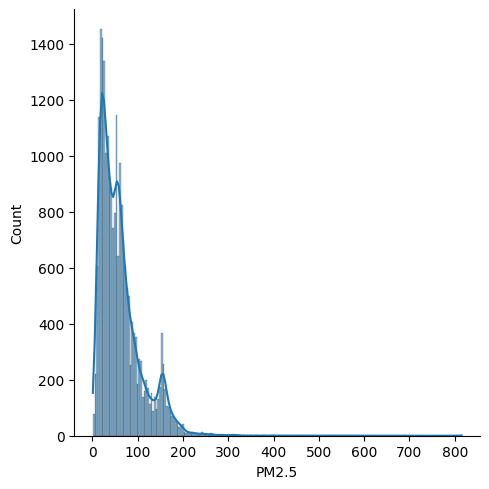

In [8]:
# plot y_train and save figure

plot = sns.displot(y_train, kde=True)
plot.set_axis_labels("PM2.5", "Count")
plt.savefig('images/plot_y_train_distribution.png', dpi=300, bbox_inches='tight')

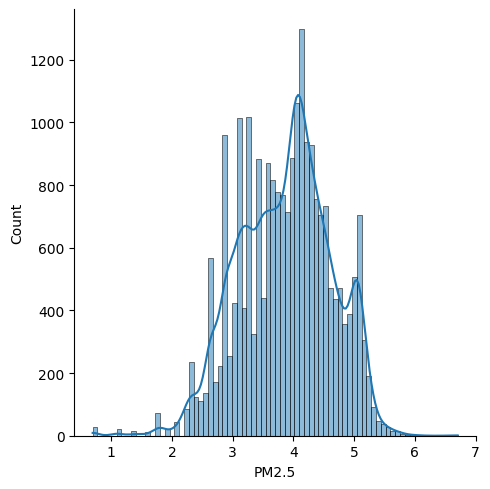

In [9]:
# logtransform y_train and save plot figure
# do not use y_train_transformed below as this is done in pipeline later

y_train_transformed = np.log1p(y_train)
plot = sns.displot(y_train_transformed, kde=True)
plot.set_axis_labels("PM2.5", "Count")
plt.savefig('images/plot_y_train_transformed.png', dpi=300, bbox_inches='tight')

In [10]:
# air quality bins

aqi_bins = [0, 12, 35.4, 55.4, 150.4, 250.4, float("inf")]
aqi_labels = [
    "Good",
    "Moderate",
    "Unhealthy (Sensitive)",
    "Unhealthy",
    "Very Unhealthy",
    "Hazardous"
]


In [11]:
# median air quality per place

place_aqi = (
    df_raw
    .groupby("Place_ID")["target"]
    .median()
    .reset_index()
)

# df with categorical AQI values
place_aqi["AQI_category"] = pd.cut(
    place_aqi["target"],
    bins=aqi_bins,
    labels=aqi_labels,
    include_lowest=True
)


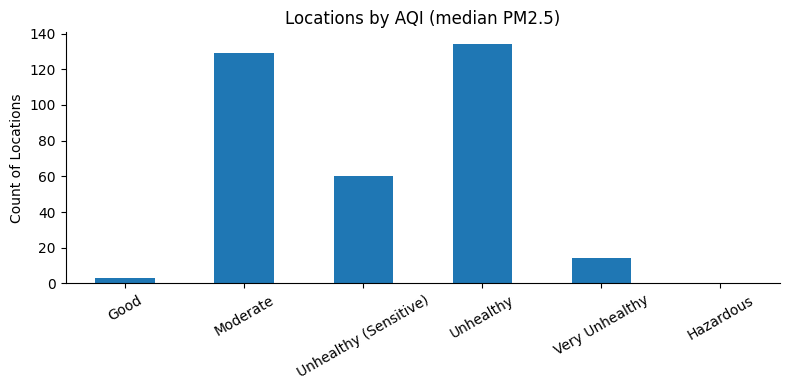

In [12]:
# count aqi per place_ID

aqi_counts = place_aqi["AQI_category"].value_counts().sort_index()

# plot
plt.figure(figsize=(8, 4))
ax = aqi_counts.plot(kind="bar")
plt.ylabel("Count of Locations")
ax.set_xlabel("")  # remove 'AQI_category'
plt.title("Locations by AQI (median PM2.5)")

# remove spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=30)
plt.tight_layout()

# first save then show
plt.savefig('images/plot_aqi_locations.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
# List of all trace gases re column_number_density


trace_gases = [
    'L3_CO_CO_column_number_density',
    'L3_NO2_NO2_column_number_density',
    'L3_HCHO_tropospheric_HCHO_column_number_density',
    'L3_O3_O3_column_number_density', 
    'L3_SO2_SO2_column_number_density', 
    'L3_CH4_CH4_column_volume_mixing_ratio_dry_air'
]


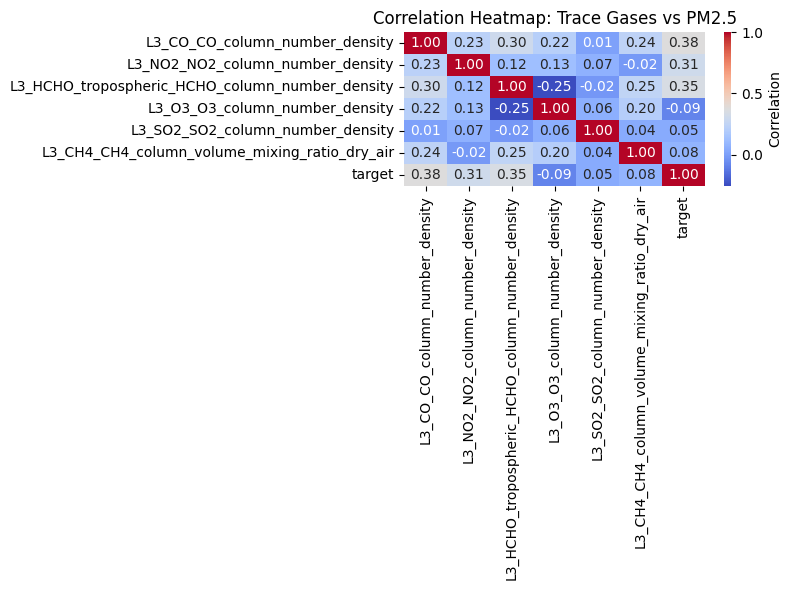

In [14]:
# get correlation of trace_gases and target

corr_with_target = df_raw[trace_gases + ['target']].corr()['target'].drop('target')
corr_with_target = corr_with_target.sort_values(ascending=False)

# correlation matrix
corr_matrix = df_raw[trace_gases + ['target']].corr()

# plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,        # show correlation values
    fmt=".2f", 
    cmap="coolwarm", 
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Heatmap: Trace Gases vs PM2.5")
plt.tight_layout()
plt.show()


In [64]:
# air pollution by weekday

# ensure datetime
X_train["Date"] = pd.to_datetime(X_train["Date"])

# weekday: Monday=0, Sunday=6
X_train["weekday"] = X_train["Date"].dt.weekday

# split
X_weekdays = X_train[X_train["weekday"] < 5].copy()
X_weekends = X_train[X_train["weekday"] >= 5].copy()

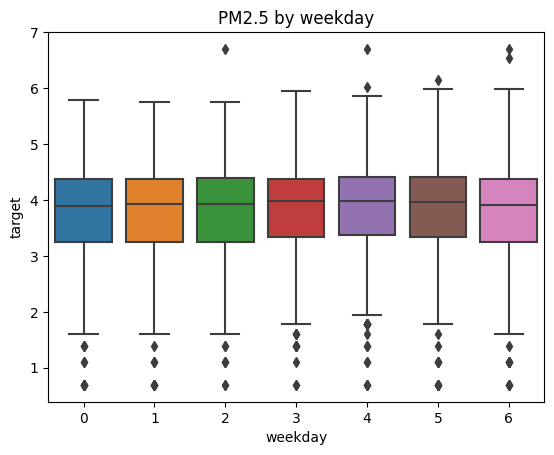

In [16]:
# show weekdays
sns.boxplot(x=X_train['weekday'], y=np.log1p(y_train)) # log transform locally
plt.title("PM2.5 by weekday")
plt.show()

In [17]:
# mean PM2.5 concentration per place_ID

X_train.assign(y=y_train).groupby('Place_ID')['y'].mean().sort_values()


Place_ID
J3C3IAI      2.428571
SI12552     11.472222
1ZBVIMD     11.859155
7DRFQCK     14.590909
RFQQX9G     14.863014
              ...    
IM6VR3X    153.757143
WMD80ZE    154.927536
EE8C6RP    159.449275
JABMGKI    171.632353
THZR2TS    201.816901
Name: y, Length: 340, dtype: float64

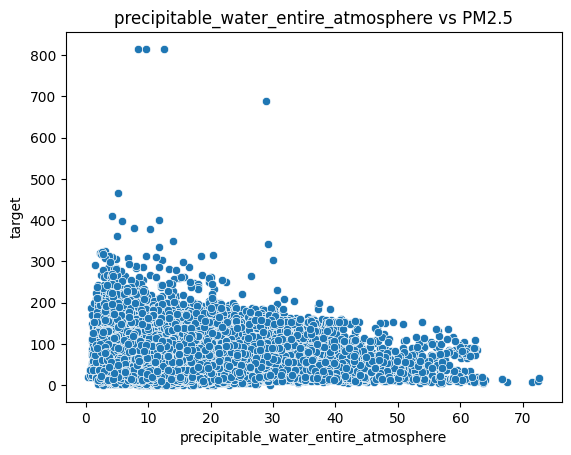

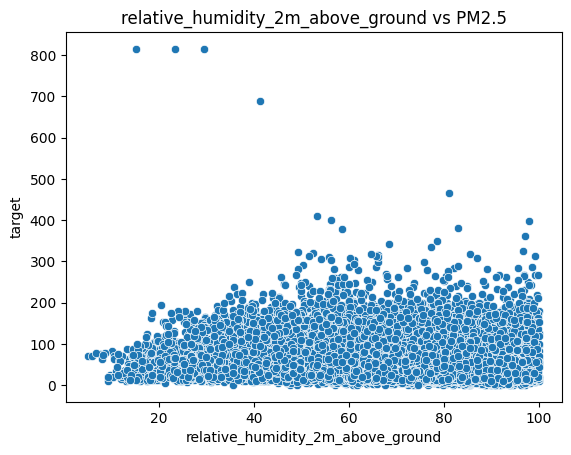

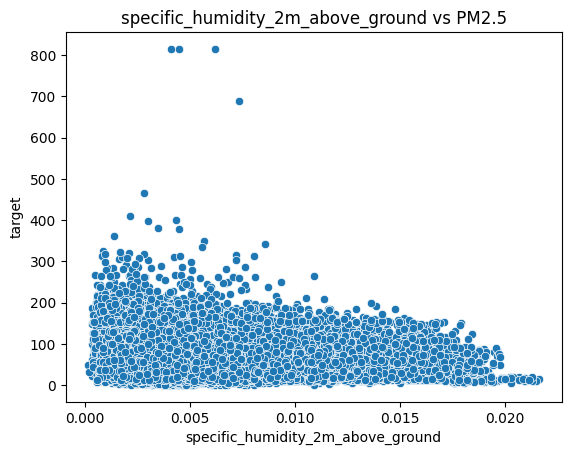

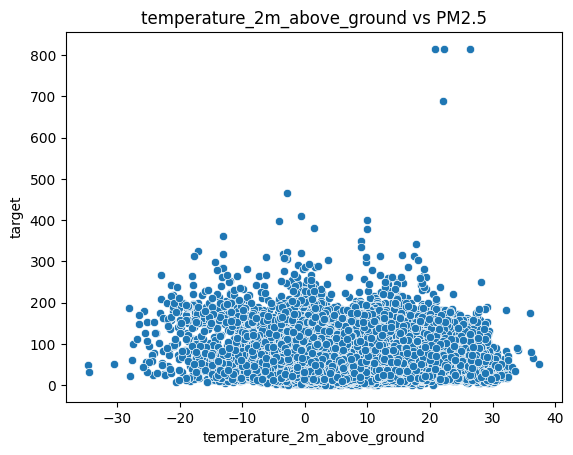

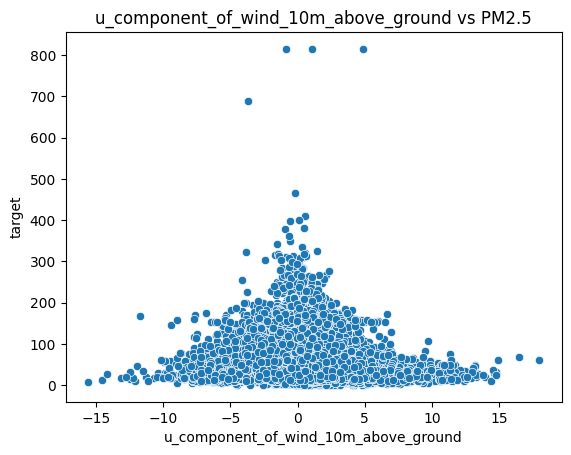

In [18]:
# plot of top 3 correlation features - take only numeric features
numeric_X = X_train.select_dtypes(include=np.number)
corr_with_target = numeric_X.corrwith(y_train)


top_features = corr_with_target.head(5).index
for f in top_features:
    sns.scatterplot(x=X_train[f], y=y_train)
    plt.title(f"{f} vs PM2.5")
    plt.show()


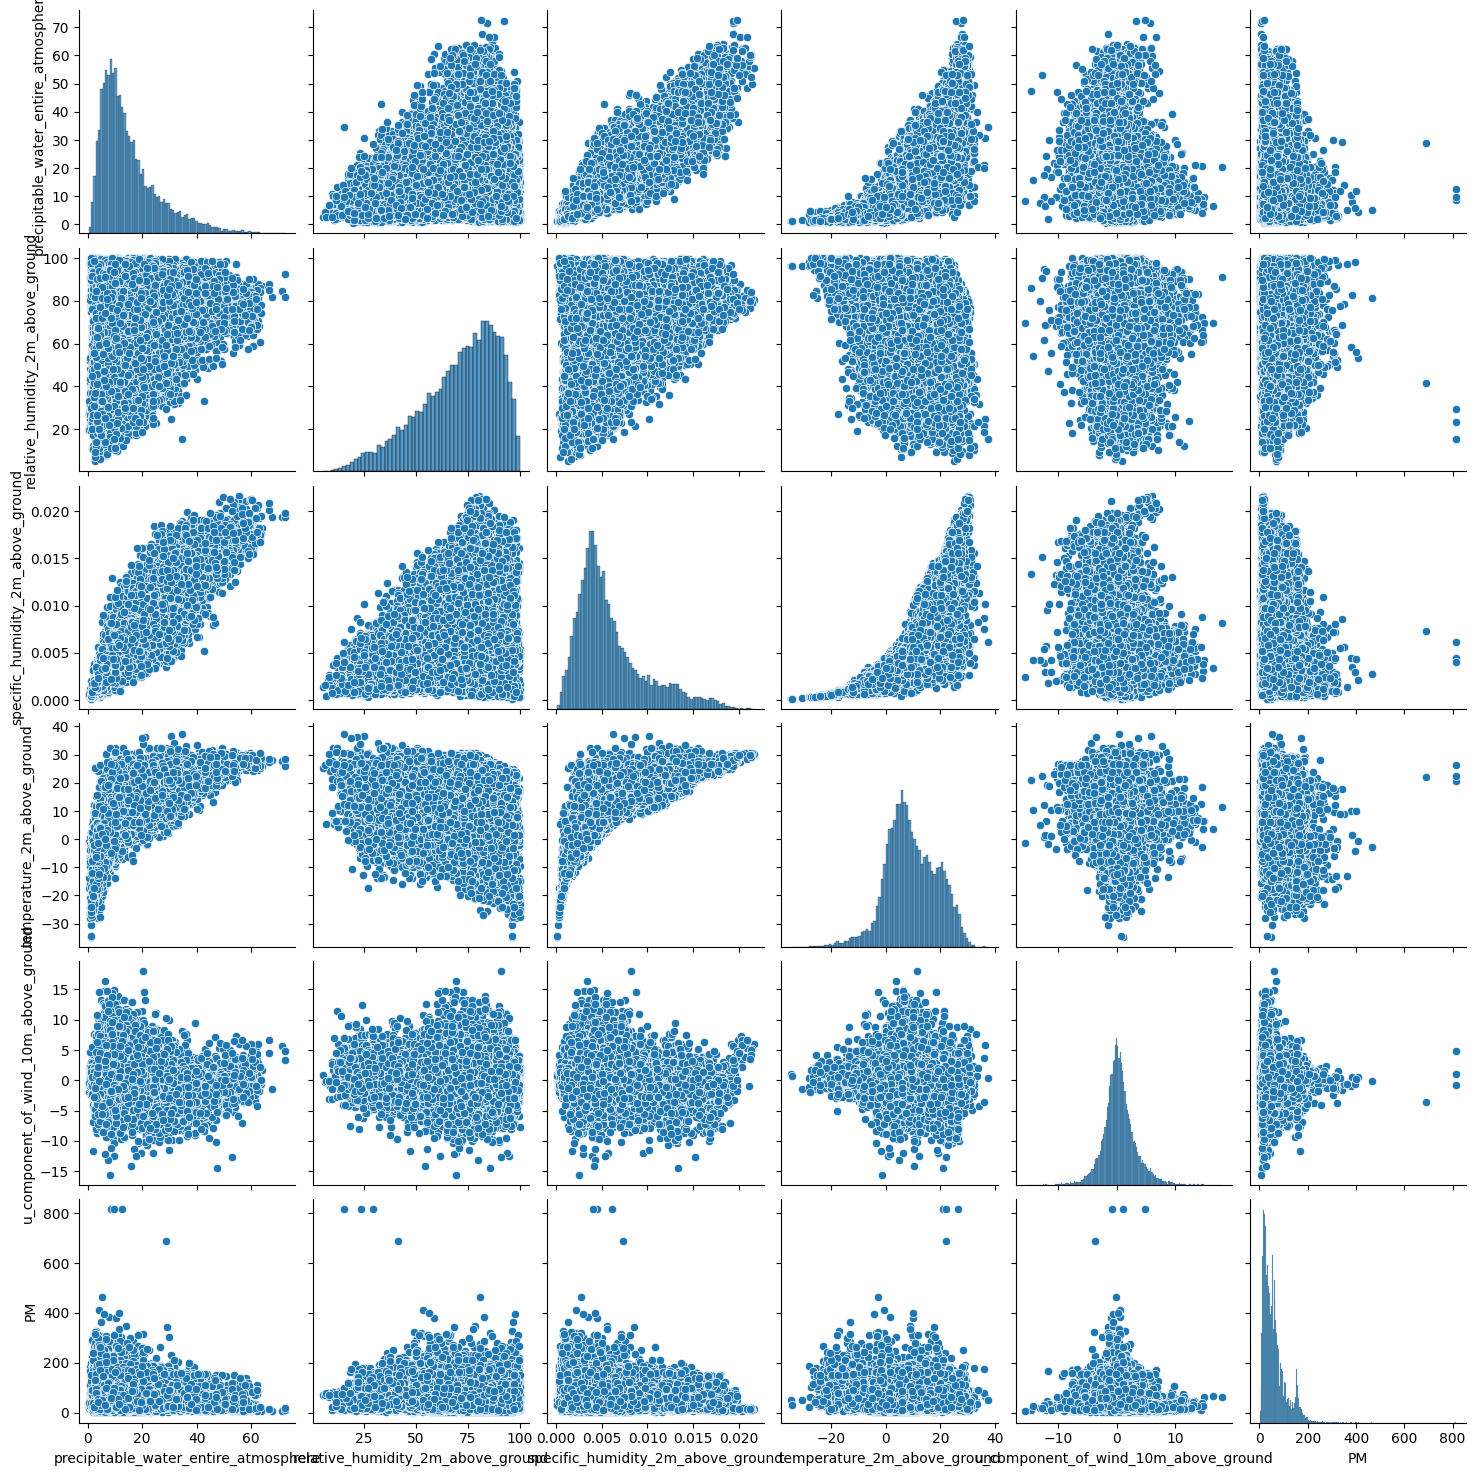

In [19]:
# top 3 corr features
sns.pairplot(X_train[top_features].assign(PM=y_train))
plt.show()


In [20]:
# % of missing values

missing_pct = X_train.isnull().sum() * 100 / len(X_train)
print("Missing % per feature:")
print(missing_pct.sort_values(ascending=False))


Missing % per feature:
L3_CH4_solar_zenith_angle               81.17991
L3_CH4_solar_azimuth_angle              81.17991
L3_CH4_sensor_zenith_angle              81.17991
L3_CH4_sensor_azimuth_angle             81.17991
L3_CH4_aerosol_optical_depth            81.17991
                                          ...   
specific_humidity_2m_above_ground        0.00000
relative_humidity_2m_above_ground        0.00000
precipitable_water_entire_atmosphere     0.00000
Place_ID                                 0.00000
weekday                                  0.00000
Length: 78, dtype: float64


In [21]:
# df with missing values in df_raw

missing_df = pd.DataFrame({
    'missing_count': X_train.isnull().sum(),
    'missing_pct': missing_pct.round(2)
}).sort_values('missing_pct', ascending=False)

missing_df

,missing_count,missing_pct
L3_CH4_solar_zenith_angle,18604,81.18
L3_CH4_solar_azimuth_angle,18604,81.18
L3_CH4_sensor_zenith_angle,18604,81.18
L3_CH4_sensor_azimuth_angle,18604,81.18
L3_CH4_aerosol_optical_depth,18604,81.18
...,...,...
specific_humidity_2m_above_ground,0,0.00
relative_humidity_2m_above_ground,0,0.00
precipitable_water_entire_atmosphere,0,0.00
Place_ID,0,0.00


In [22]:
# fit and transform rows not missing more than 20% values

class RowFilterByMissingness(BaseEstimator, TransformerMixin):
    def __init__(self, max_missing_fraction=0.20):
        self.max_missing_fraction = max_missing_fraction

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # compute mask for rows to keep
        self.keep_mask_ = X.isna().mean(axis=1) <= self.max_missing_fraction
        return X.loc[self.keep_mask_].copy()

    def transform_y(self, y):
        return y.loc[self.keep_mask_].copy()

In [23]:
# drop categorical columns and CH4 columns (drop_cols = missing values >80%)

class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, drop_cols=None, cat_cols=None):
        self.drop_cols = drop_cols or []
        self.cat_cols = cat_cols or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(self.drop_cols + self.cat_cols, axis=1, errors="ignore")

In [24]:
# has to run after RowFilterByMissingness and ColumnDropper!

# impute median of remaining missing values
class ColumnMedianImputer(BaseEstimator, TransformerMixin):
    """Impute numeric columns with median"""
    def __init__(self):
        self.medians_ = None

    def fit(self, X, y=None):
        self.medians_ = X.median()
        return self

    def transform(self, X):
        return X.fillna(self.medians_)

In [25]:
# drop columns with % of missing values > 80

drop_cols = ['L3_CH4_CH4_column_volume_mixing_ratio_dry_air', 
            'L3_CH4_aerosol_height', 
            'L3_CH4_aerosol_optical_depth', 
            'L3_CH4_sensor_azimuth_angle',
            'L3_CH4_sensor_zenith_angle',
            'L3_CH4_solar_azimuth_angle',
            'L3_CH4_solar_zenith_angle']

# categorical columns
cat_cols = ['Place_ID X Date', 'Date', 'Place_ID']
             


In [26]:
# preprocess pipeline: filter rows, drop columns, impute missing values for remainder

preprocess_pipeline = Pipeline(
    steps=[
        ("row_filter", RowFilterByMissingness(max_missing_fraction=0.20)),
        ("column_dropper", ColumnDropper(drop_cols=drop_cols, cat_cols=cat_cols)),
        ("median_imputer", ColumnMedianImputer())
    ]
)


In [27]:
# fit and transform cleaning pipeline on X_train to yield X_train_clean
X_train_clean = preprocess_pipeline.fit_transform(X_train, y_train)

# apply identical row filter to yield y_train_clean
row_filter = preprocess_pipeline.named_steps['row_filter']
y_train_clean = row_filter.transform_y(y_train)

In [28]:
# check alignment for X_train_clean after data cleaning. If breaks, sth upstream is broken.
assert X_train_clean.index.equals(y_train_clean.index)

In [29]:
# transform cleaning pipeline for X_test
X_test_clean = preprocess_pipeline.transform(X_test)

In [30]:
# filter test target separately
row_missing_fraction_test = X_test.isna().mean(axis=1)
keep_mask_test = row_missing_fraction_test <= 0.20
y_test_clean = y_test.loc[keep_mask_test]

In [31]:
# check alignment for X_test_clean after data cleaning
assert X_test_clean.index.equals(y_test_clean.index)

In [32]:
# X_test_clean is shorter by 1 column - 'target'
print(f"Training shape: {X_train_clean.shape}, Target: {y_train_clean.shape}")
print(f"Test shape: {X_test_clean.shape}, Target: {y_test_clean.shape}")

Training shape: (16805, 68), Target: (16805,)
Test shape: (5566, 67), Target: (5566,)


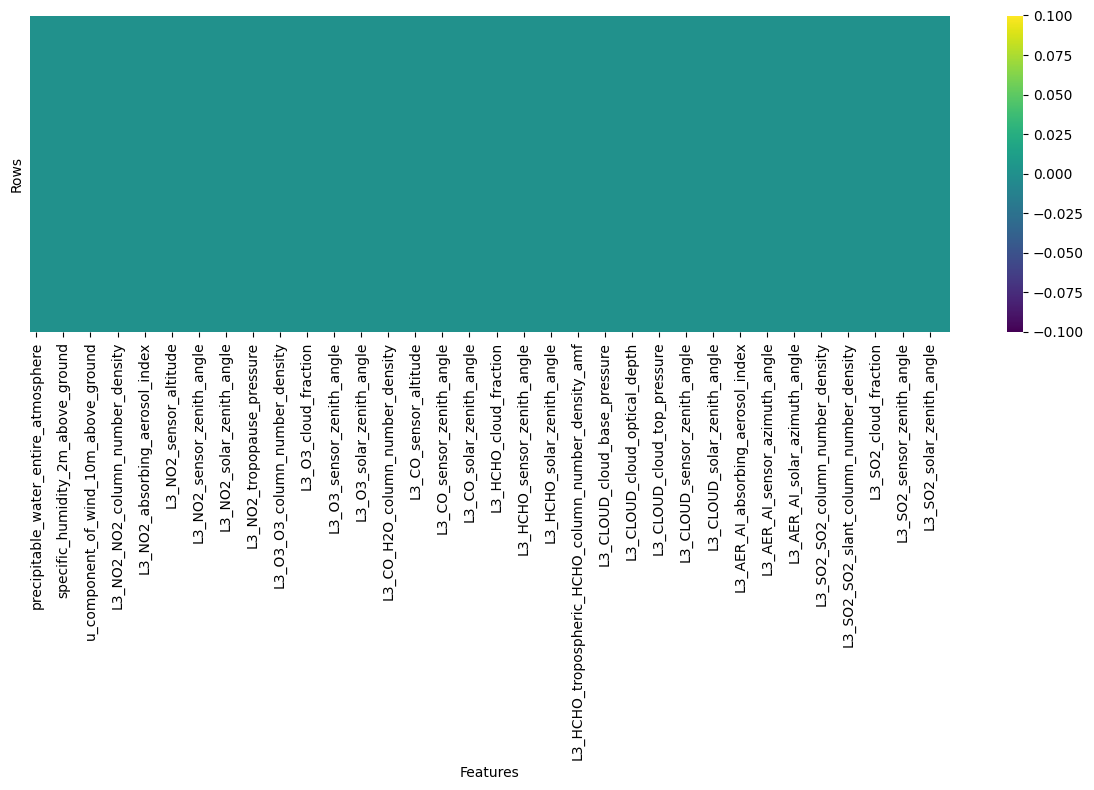

In [33]:
# heatmap of missing values

# Missing values matrix (0=complete, 1=missing)
missing_matrix = X_train_clean.isnull()

plt.figure(figsize=(12, 8))
sns.heatmap(missing_matrix, 
            #cbar=True, 
            yticklabels=False, 
            cmap='viridis')

#plt.title('Missing Values Heatmap - X_train')
plt.xlabel('Features')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()


## 3. Baseline Model

In [34]:
# create baseline model, takes mean of y and predicts y (unlogged)

baseline_model = DummyRegressor(strategy='mean')
baseline_model.fit(X_train_clean, y_train_clean) 

DummyRegressor()

In [35]:
# compute predicted target
y_pred_baseline = baseline_model.predict(y_test) 

In [36]:
# baseline model - evaluation metric rmse
baseline_rmse = round(np.sqrt(mean_squared_error(y_test,y_pred_baseline)),6)
baseline_rmse

46.469336

In [37]:
# alternative baseline model using TransformedTargetRegressor
# learns mean(log(y)) and predicts exp(mean(log(y)))
baseline_model = TransformedTargetRegressor(
    regressor=DummyRegressor(strategy="mean"),
    func=np.log1p,
    inverse_func=np.expm1
)

baseline_model.fit(X_train_clean, y_train_clean)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=DummyRegressor())

In [38]:
y_pred_baseline = baseline_model.predict(X_test_clean)


In [39]:
baseline_rmse = round(np.sqrt(mean_squared_error(y_test_clean, y_pred_baseline)),6)
print(f"Alternative Baseline RMSE = {baseline_rmse}")


Alternative Baseline RMSE = 50.025207


## 4. Model Pipeline

In [40]:
# compute feature/target correlations of top10 features

top_10_features = (
    corr_with_target
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

# top 10 features w pos and neg values
top_10_features_signed = corr_with_target.loc[top_10_features.index]
top_10_features_signed


L3_CO_CO_column_number_density                     0.378532
L3_HCHO_tropospheric_HCHO_column_number_density    0.348518
L3_HCHO_HCHO_slant_column_number_density           0.324616
L3_NO2_NO2_slant_column_number_density             0.316730
L3_AER_AI_sensor_altitude                         -0.306957
L3_NO2_NO2_column_number_density                   0.305817
L3_NO2_tropospheric_NO2_column_number_density      0.298988
L3_AER_AI_solar_azimuth_angle                     -0.192010
L3_CLOUD_solar_azimuth_angle                      -0.186774
L3_O3_solar_azimuth_angle                         -0.184829
dtype: float64

In [41]:

#top1 feature
FEATURES_1 = ["L3_CO_CO_column_number_density"]

# top10 feature
FEATURES_TOP10 = [
    "L3_CO_CO_column_number_density",
    "L3_HCHO_tropospheric_HCHO_column_number_density",
    "L3_HCHO_HCHO_slant_column_number_density",
    "L3_NO2_NO2_slant_column_number_density",
    "L3_NO2_NO2_column_number_density",
    "L3_AER_AI_sensor_altitude",
    "L3_NO2_tropospheric_NO2_column_number_density",
    "L3_AER_AI_solar_azimuth_angle",
    "L3_CLOUD_solar_azimuth_angle",
    "L3_O3_solar_azimuth_angle"
]


In [42]:
# train first model with strongest features

# fit and transform feature
class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, features):
        self.features = features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.features].copy()

In [43]:
# pipeline to select features, scale around center 0 and apply ridge regression

model_pipeline = Pipeline(
    steps=[
        ("feature_selector", FeatureSelector(FEATURES_TOP10)),
        ("scaler", StandardScaler()),
        ("regressor", Ridge())
    ]
)

In [44]:
# apply logtransform to y_train_clean (unlogged)

model = TransformedTargetRegressor(
    regressor=model_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)


In [45]:
# fit first model

model_pipeline.fit(X_train_clean, y_train_clean)


Pipeline(steps=[('feature_selector',
                 FeatureSelector(features=['L3_CO_CO_column_number_density',
                                           'L3_HCHO_tropospheric_HCHO_column_number_density',
                                           'L3_HCHO_HCHO_slant_column_number_density',
                                           'L3_NO2_NO2_slant_column_number_density',
                                           'L3_NO2_NO2_column_number_density',
                                           'L3_AER_AI_sensor_altitude',
                                           'L3_NO2_tropospheric_NO2_column_number_density',
                                           'L3_AER_AI_solar_azimuth_angle',
                                           'L3_CLOUD_solar_azimuth_angle',
                                           'L3_O3_solar_azimuth_angle'])),
                ('scaler', StandardScaler()), ('regressor', Ridge())])

In [46]:
# fit model - ignore logtransform here. that's done inside model

model.fit(X_train_clean, y_train_clean)


TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('feature_selector',
                                                      FeatureSelector(features=['L3_CO_CO_column_number_density',
                                                                                'L3_HCHO_tropospheric_HCHO_column_number_density',
                                                                                'L3_HCHO_HCHO_slant_column_number_density',
                                                                                'L3_NO2_NO2_slant_column_number_density',
                                                                                'L3_NO2_NO2_column_number_density',
                                                                                'L3_AER_AI_sensor_altitude',
                                                                                'L3_NO2_tropospheric_NO2_column_number_density',
                                                                                'L3_AER_AI_solar_azimuth_angle',
                                                                                'L3_CLOUD_solar_azimuth_angle',
                                                                                'L3_O3_solar_azimuth_angle'])),
                                                     ('scaler',
                                                      StandardScaler()),
                                                     ('regressor', Ridge())]))

In [53]:
# models to train
models = {
    'LinearReg': LinearRegression(),
    'KNN': KNeighborsRegressor(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1)
}

results = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('model', model)
    ])
    
    # cross calidation
    cv_scores = cross_val_score(pipeline, X_train_clean, y_train_clean, cv=kf, scoring='neg_mean_squared_error')
    
    # convert back to RMSE (approximate for log space)
    rmse_scores = np.sqrt(-cv_scores)
    results[name] = rmse_scores.mean()
    print(f"{name} CV RMSE: {results[name]:.4f}")

# select best model for tuning
best_model_name = min(results, key=results.get)
print(f"Best initial model: {best_model_name}")


LinearReg CV RMSE: 36.6083
KNN CV RMSE: 34.6752
RandomForest CV RMSE: 30.3530
GradientBoosting CV RMSE: 32.6046
XGBoost CV RMSE: 30.0883
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17092
[LightGBM] [Info] Number of data points in the train set: 13444, number of used features: 68
[LightGBM] [Info] Start training from score 64.060622
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17092
[LightGBM] [Info] Number of data points in the train set: 13444, number of used features: 68
[LightGBM] [Info] Start training from score 64.006620
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001417 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

## 5. Hyperparameter Tuning

In [ ]:
# currently broken - 

# tune LightGBM 
# using GridSearchCV OR RandomizedSearchCV?

param_grid_lgbm = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, 20, None],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [31, 50, 100]
}

# pipeline for LightGBM tuning
lgbm_pipeline = Pipeline([
    ('scaler', RobustScaler()),          #optional 
    ('model', LGBMRegressor(random_state=42))
])

# Grid search
grid_lgbm = GridSearchCV(
    lgbm_pipeline,
    param_grid_lgbm,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit on training data
grid_lgbm.fit(X_train_clean, y_train_clean)

print(f"Best LightGBM Params: {grid_lgbm.best_params_}")
print(f"Best LightGBM CV RMSE: {np.sqrt(-grid_lgbm.best_score_):.4f}")

# Save best estimator
best_lgbm = grid_lgbm.best_estimator_


In [ ]:
# tbd

# hyperparameter tuning on lgb

param_grid_lgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, 15],
    'model__num_leaves': [31, 63],
    'model__min_data_in_leaf': [20, 50],
    'model__learning_rate': [0.05, 0.1]
}


lgb_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', LGBMRegressor(random_state=42, n_jobs=-1, max_bin=255, force_row_wise=True))
])

grid_lgb = GridSearchCV(
    lgb_pipeline,
    param_grid_lgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_lgb.fit(X_train_clean, y_train_clean)

print(f"Best LightGBM Params: {grid_lgb.best_params_}")
best_lgbm = grid_lgb.best_estimator_

In [48]:
# tune RandomForest using GridSearchCV

param_grid_rf = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

# pipeline for tuning
rf_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', RandomForestRegressor(random_state=42))
])


grid = GridSearchCV(rf_pipeline, param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X_train_clean, y_train_clean)

print(f"Best Params: {grid.best_params_}")
print(f"Best RMSE: {np.sqrt(-grid.best_score_):.4f}")

best_rf = grid.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best RMSE: 30.7284


## 6. Ensembling

In [49]:
# split into subsets for stacking
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_clean,
    y_train_clean,
    test_size=0.2,
    random_state=42
)

In [50]:
# combine linear regression, KNN, and tuned RF

estimators = [
    ('lr', Pipeline([('scaler', RobustScaler()), ('model', LinearRegression())])),
    ('knn', Pipeline([('scaler', RobustScaler()), ('model', KNeighborsRegressor())])),
    ('rf', best_rf)
]

stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)


# fit on training subset
stacking_regressor.fit(X_train_sub, y_train_sub)

# predict on validation set
stack_pred = stacking_regressor.predict(X_val)

# compute RMSE
stack_rmse = np.sqrt(mean_squared_error(y_val, stack_pred))
print(f"Stacked Ensemble RMSE on Validation Set: {stack_rmse:.4f}")

Stacked Ensemble RMSE on Validation Set: 28.6762


In [59]:
# alternative stacking - tbd

# Define estimators: use tuned versions
estimators = [
    ('rf', best_rf),
    #('xgb', best_xgb),       # assume you tuned XGBoost similarly
    #('lgbm', best_lgbm)
]

# Final estimator can be linear regression or a simple model
stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),   # meta-model
    n_jobs=-1
)

# Fit on full training set
stacking_regressor.fit(X_train_clean, y_train_clean)

# Predict on test set
stack_pred = stacking_regressor.predict(X_test_clean)

# Compute RMSE
stack_rmse = np.sqrt(mean_squared_error(y_test_clean, stack_pred))
print(f"Stacked Ensemble Test RMSE: {stack_rmse:.4f}")


NameError: name 'best_xgb' is not defined

## 7. Prediction

In [ ]:
# apply same row filter as training
row_filter = preprocess_pipeline.named_steps["row_filter"]
y_test_clean = row_filter.transform_y(y_test)  # aligns with X_test_clean

# evaluate
y_pred_test = best_lgbm.predict(X_test_clean)
test_rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_test))
print(f"LightGBM Test RMSE: {test_rmse:.4f}")

In [63]:
# simple prediction - tbd

# pick best model based on CV
best_model = models[best_model_name]

# create pipeline (with scaling) for training
best_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', best_model)
])

# fit on full training data
best_pipeline.fit(X_train_clean, y_train_clean)

# transform test target with same row filter as training
row_filter = preprocess_pipeline.named_steps["row_filter"]
y_test_clean = row_filter.transform_y(y_test)

# predict on test set
y_pred_test = best_pipeline.predict(X_test_clean)

# compute RMSE
test_rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_test))
print(f"Test RMSE for {best_model_name}: {test_rmse:.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001762 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17092
[LightGBM] [Info] Number of data points in the train set: 16805, number of used features: 68
[LightGBM] [Info] Start training from score 63.943529


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- weekday
